## Test functions for run analysis

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from src.paths import *
from src.utils import compare_inis
from src.models import generate_HBV_parameters

import xarray as xr
import matplotlib.pyplot as plt

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


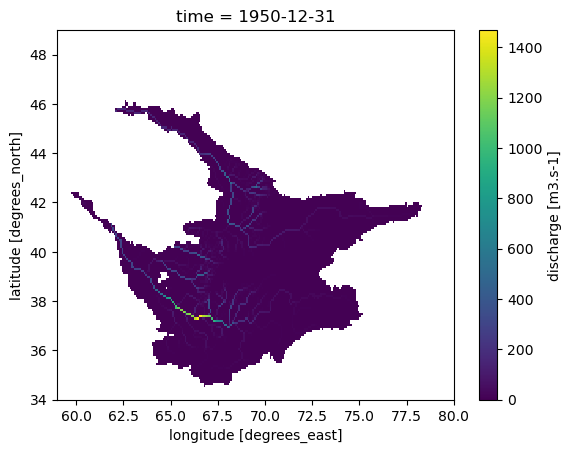

In [2]:
path_to_file_2rivers = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/pcrglobwb_20260114_124319/netcdf/discharge_dailyTot_output.nc"
ds_2riv = xr.open_dataset(path_to_file_2rivers)
ds_2riv['discharge'].isel(time=-1).plot()


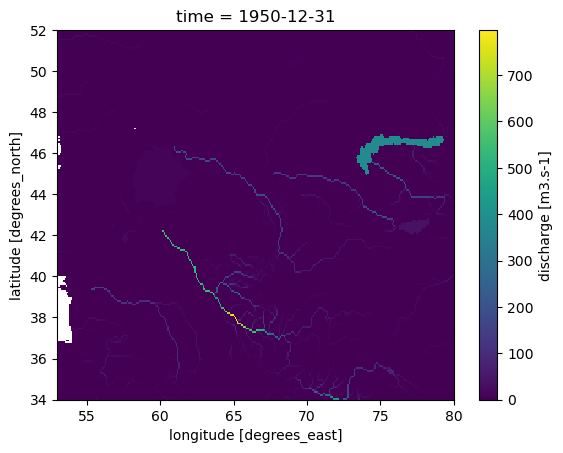

In [3]:
path_to_file_basin = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/pcrglobwb_20260114_132449/netcdf/discharge_dailyTot_output.nc"
ds_basin = xr.open_dataset(path_to_file_basin)
ds_basin['discharge'].isel(time=-1).plot()


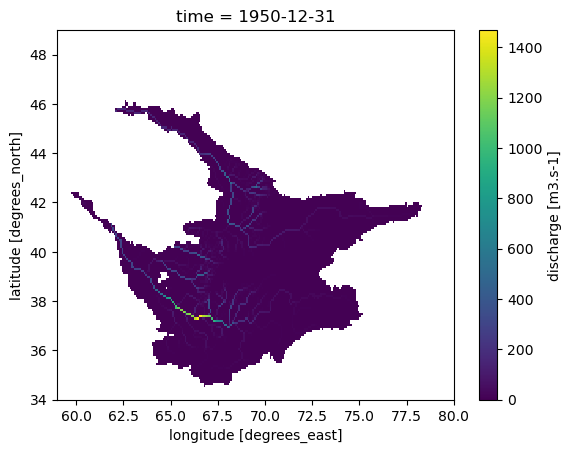

In [4]:
path_to_file_2riv_2 = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/pcrglobwb_20260114_141338/netcdf/discharge_dailyTot_output.nc"
ds_2riv_2nd = xr.open_dataset(path_to_file_2riv_2)
ds_2riv_2nd['discharge'].isel(time=-1).plot()

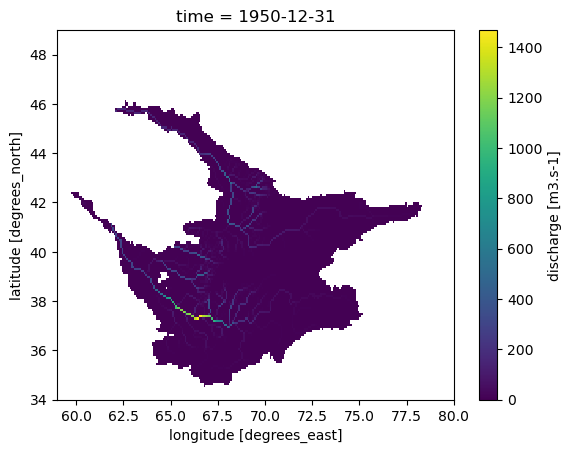

In [5]:
path_to_file_2riv_C = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/test_py_function/pcrglobwb_20260114_143602/netcdf/discharge_dailyTot_output.nc"
ds_2riv_C = xr.open_dataset(path_to_file_2riv_C)
ds_2riv_C['discharge'].isel(time=-1).plot()

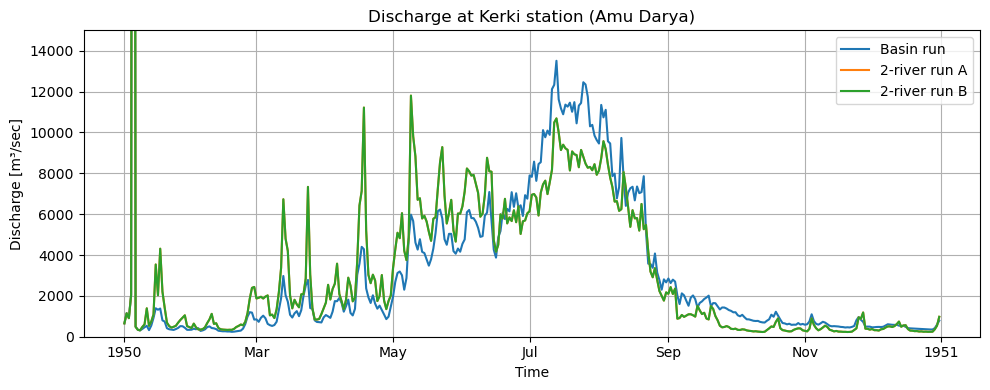

In [6]:
Kerki_station_latitude = 37.8396310038444 #Amu Darya near Kerki
Kerki_station_longitude = 65.23703868931334

lat_pt = 45.0
lon_pt = 60.0

q_point_basin = ds_basin["discharge"].sel(
    lat=Kerki_station_latitude,
    lon=Kerki_station_longitude,
    method="nearest"
)

q_point_2riv = ds_2riv["discharge"].sel(
    lat=Kerki_station_latitude,
    lon=Kerki_station_longitude,
    method="nearest"
)

q_point_2riv2nd = ds_2riv_2nd["discharge"].sel(
    lat=Kerki_station_latitude,
    lon=Kerki_station_longitude,
    method="nearest"
)

fig, ax = plt.subplots(figsize=(10, 4))

q_point_basin.plot(
    ax=ax,
    label="Basin run",
)

q_point_2riv.plot(
    ax=ax,
    label="2-river run A",
)

q_point_2riv2nd.plot(
    ax=ax,
    label="2-river run B",
)


ax.set_xlabel("Time")
ax.set_ylabel("Discharge [m³/sec]")  # adjust if you convert to m³/s
ax.set_title("Discharge at Kerki station (Amu Darya)")

ax.legend()
ax.grid(True)


plt.ylim(0,15000)
plt.tight_layout()
plt.show()

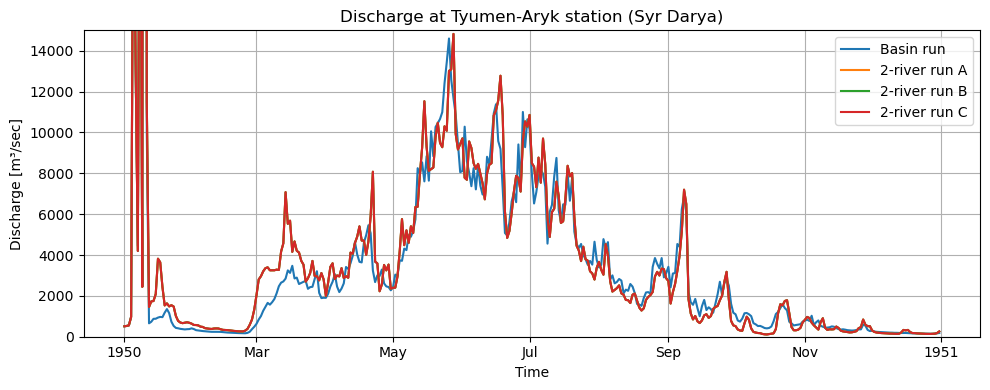

In [7]:
station_latitude = 44.05-0.1 # Syr Darya near Tyumen, through trial and error
station_longitude = 67.05

lat_pt = 45.0
lon_pt = 60.0

q_point_basin = ds_basin["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)

q_point_2riv = ds_2riv["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)

q_point_2riv2nd = ds_2riv_2nd["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)

q_point_2rivC = ds_2riv_C["discharge"].sel(
    lat=station_latitude,
    lon=station_longitude,
    method="nearest"
)


fig, ax = plt.subplots(figsize=(10, 4))

q_point_basin.plot(
    ax=ax,
    label="Basin run",
)

q_point_2riv.plot(
    ax=ax,
    label="2-river run A",
)

q_point_2riv2nd.plot(
    ax=ax,
    label="2-river run B",
)
q_point_2rivC.plot(
    ax=ax,
    label="2-river run C",
)


ax.set_xlabel("Time")
ax.set_ylabel("Discharge [m³/sec]")  # adjust if you convert to m³/s
ax.set_title("Discharge at Tyumen-Aryk station (Syr Darya)")

ax.legend()
ax.grid(True)


plt.ylim(0,15000)
plt.tight_layout()
plt.show()

[[1.10196775e+01 5.41634585e-01 3.79592443e+02 7.13279900e-01
  2.32457278e-01 1.10815417e+01 1.09539455e-02 1.07703080e-03
  3.66470068e-01]
 [1.65350165e+01 2.84036151e-01 6.94783393e+02 2.00658292e+00
  2.27314611e-02 4.59772553e+00 1.58289947e-02 7.19261986e-03
  1.32371454e-01]
 [3.54601359e+00 7.12273774e-01 7.16452058e+02 1.32405502e+00
  1.60086884e-01 5.41637716e+00 1.70720403e-02 3.86812140e-03
  3.11088712e-02]
 [1.07933148e+01 2.57599779e-01 5.72980685e+02 1.57969427e+00
  2.11873974e-01 8.65016061e+00 1.75504788e-02 9.58572104e-03
  1.34225256e-01]
 [1.16957398e+01 9.20321216e-01 3.51423342e+02 3.22899826e+00
  2.23875085e-01 2.30262618e+00 1.38782244e-02 7.63749399e-03
  4.06260771e-01]
 [2.30846661e+01 6.41088284e-01 4.96535824e+02 1.85410785e+00
  1.00097799e-01 8.16682411e+00 1.36540948e-02 6.86258699e-03
  3.31968477e-01]
 [7.69991693e+00 6.32001764e-01 4.05875035e+02 5.74024875e-01
  1.97158280e-01 1.28238520e+01 1.76706706e-02 2.03733224e-03
  6.64107676e-01]
 [2.37